<a href="https://colab.research.google.com/github/serdararici/btk-datathon-2026/blob/main/notebooks/v1_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Datathon 2026 - V1: EDA & Baseline Model
**Goal:** Predict career_success_score (0-100) | **Metric:** MSE
**Author:** Serdar Arıcı | **Date:** June 2026

SyntaxError: invalid syntax (1436226265.py, line 2)

In [4]:
# ============================================================
# SECTION 1: MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Define the path to your data folder in Drive
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/btk-datathon-2026/'
DATASET_PATH = DATA_PATH + 'datasets/'
OUTPUT_PATH  = DATA_PATH + 'outputs/'

print("Drive mounted successfully!")
print(f"Data path: {DATA_PATH}")

Mounted at /content/drive
Drive mounted successfully!
Data path: /content/drive/MyDrive/Colab Notebooks/btk-datathon-2026/


In [5]:
# ============================================================
# SECTION 2: IMPORTS & SETTINGS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Show all columns when printing dataframes
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded!")

Libraries loaded!


In [6]:
# ============================================================
# SECTION 3: LOAD DATA
# ============================================================

train = pd.read_csv(DATASET_PATH + 'train.csv', encoding='utf-8-sig')
test  = pd.read_csv(DATASET_PATH + 'test_x.csv', encoding='utf-8-sig')

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")

train.head(3)

Train: (10000, 47)
Test:  (10000, 46)


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,career_success_score,mentor_feedback_text
0,STU_000001,2021,21,2021,Computer Engineering,Tier 4,3.17,62.54,77.31,0,DevOps Engineer,73.28,71.11,52.91,84.98000,81.77,62.710000,71.570000,63.041897,69.952625,81.90,0,3,11.0,0,0,0,65.54,18,1.85,10.0,86.58,42.06,40.57,50.29,79.83,44.14,62.70,58.84,3,1,24,0,photography,LinkedIn,86.78,Proje kalitesi ve makine öğrenimi konusundaki ...
1,STU_000002,2024,20,2024,Computer Engineering,Tier 4,3.24,75.10,87.13,3,Backend Developer,63.12,78.90,61.81,37.45074,65.54,69.944694,60.830000,64.510000,57.940000,24.68,0,0,NaN,1,1,0,54.48,7,1.22,1.0,33.34,65.39,82.99,67.43,43.60,22.05,42.32,40.54,2,0,46,5,reading,YouTube,46.16,Kodlama ve problem çözme becerileri gelişmekte...
2,STU_000003,2024,28,2024,Electrical Electronics Engineering,Tier 4,3.00,68.53,95.64,1,Frontend Developer,100.00,86.44,83.62,85.44000,87.18,80.580000,96.433149,62.220000,81.750000,78.92,2,0,0.0,2,0,0,75.10,4,12.12,2.0,61.37,52.25,43.06,20.19,48.62,65.64,47.27,82.56,1,2,46,5,cinema,Reddit,84.08,İleri düzey frontend geliştirme becerileri ile...


In [7]:
# ============================================================
# SECTION 4: FIRST LOOK
# ============================================================

# Data types and missing value counts
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       10000 non-null  object 
 1   application_year                 10000 non-null  int64  
 2   age                              10000 non-null  int64  
 3   graduation_year                  10000 non-null  int64  
 4   department                       10000 non-null  object 
 5   university_tier                  10000 non-null  object 
 6   cgpa                             10000 non-null  float64
 7   english_exam_score               9047 non-null   float64
 8   attendance_rate                  10000 non-null  float64
 9   failed_courses_count             10000 non-null  int64  
 10  target_role                      10000 non-null  object 
 11  coding_score                     10000 non-null  float64
 12  problem_solving_sco

                                missing_count  missing_pct
internship_duration_months               1657        16.57
english_exam_score                        953         9.53
github_avg_stars                          910         9.10
open_source_contribution_count            910         9.10
hr_interview_score                        780         7.80
linkedin_profile_score                    668         6.68
portfolio_score                           364         3.64


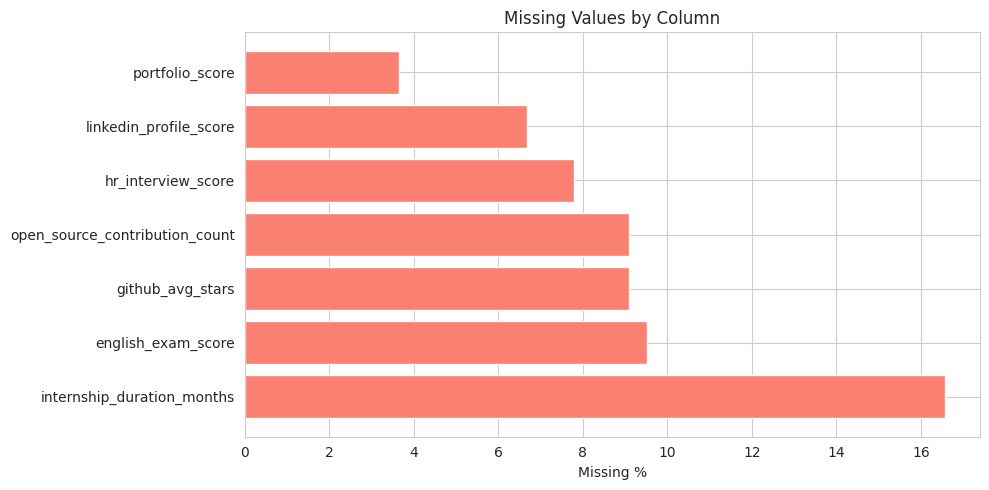

Chart saved to Drive!


In [8]:
# ============================================================
# SECTION 5: MISSING VALUE ANALYSIS
# ============================================================

# Count and percentage of missing values per column
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})
print(missing_df)

# Visualize
plt.figure(figsize=(10, 5))
plt.barh(missing_df.index, missing_df['missing_pct'], color='salmon')
plt.xlabel('Missing %')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'missing_values.png', dpi=150)
plt.show()
print("Chart saved to Drive!")

count    10000.000000
mean        76.942507
std         15.186669
min          0.000000
25%         66.937500
50%         77.810000
75%         88.472500
max        100.000000
Name: career_success_score, dtype: float64

Skewness: -0.4507


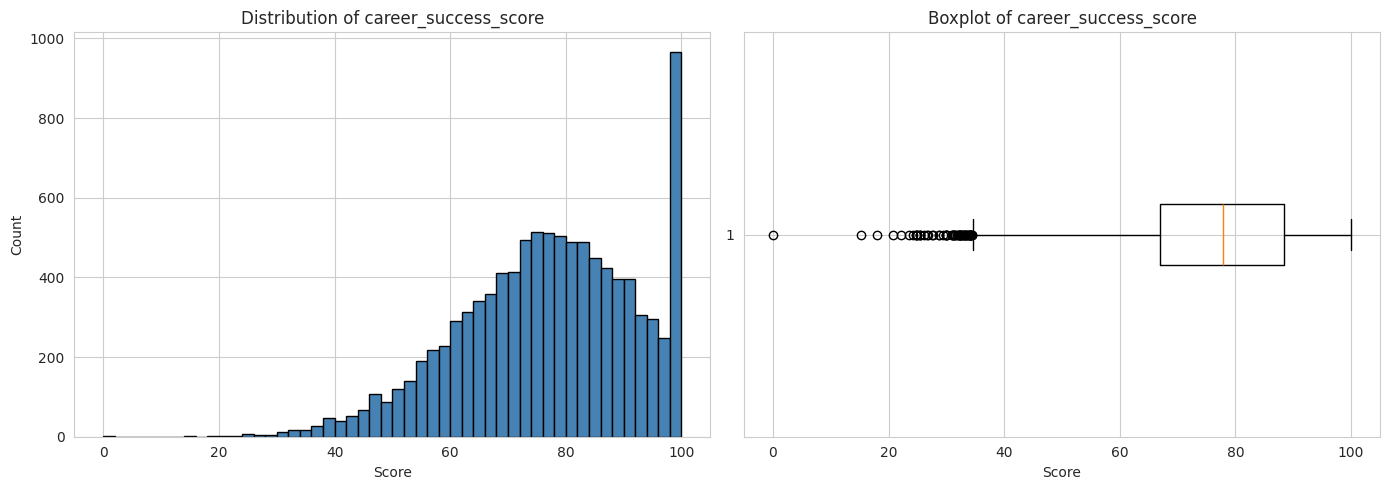

Chart saved to Drive!


In [9]:
# ============================================================
# SECTION 6: TARGET VARIABLE DISTRIBUTION
# ============================================================

target = 'career_success_score'

print(train[target].describe())
print(f"\nSkewness: {train[target].skew():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train[target], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of career_success_score')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

# Boxplot
axes[1].boxplot(train[target], vert=False)
axes[1].set_title('Boxplot of career_success_score')
axes[1].set_xlabel('Score')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'target_distribution.png', dpi=150)
plt.show()
print("Chart saved to Drive!")

Top 10 positive correlations:
project_quality_score        0.541063
technical_interview_score    0.340448
problem_solving_score        0.289990
cloud_score                  0.276863
coding_score                 0.274396
devops_score                 0.272033
portfolio_score              0.270772
backend_score                0.266532
real_client_project_count    0.258805
data_structures_score        0.251838
Name: career_success_score, dtype: float64

Bottom 5 negative correlations:
age                    -0.004306
cgpa                   -0.014919
failed_courses_count   -0.059402
graduation_year        -0.060823
application_year       -0.062786
Name: career_success_score, dtype: float64


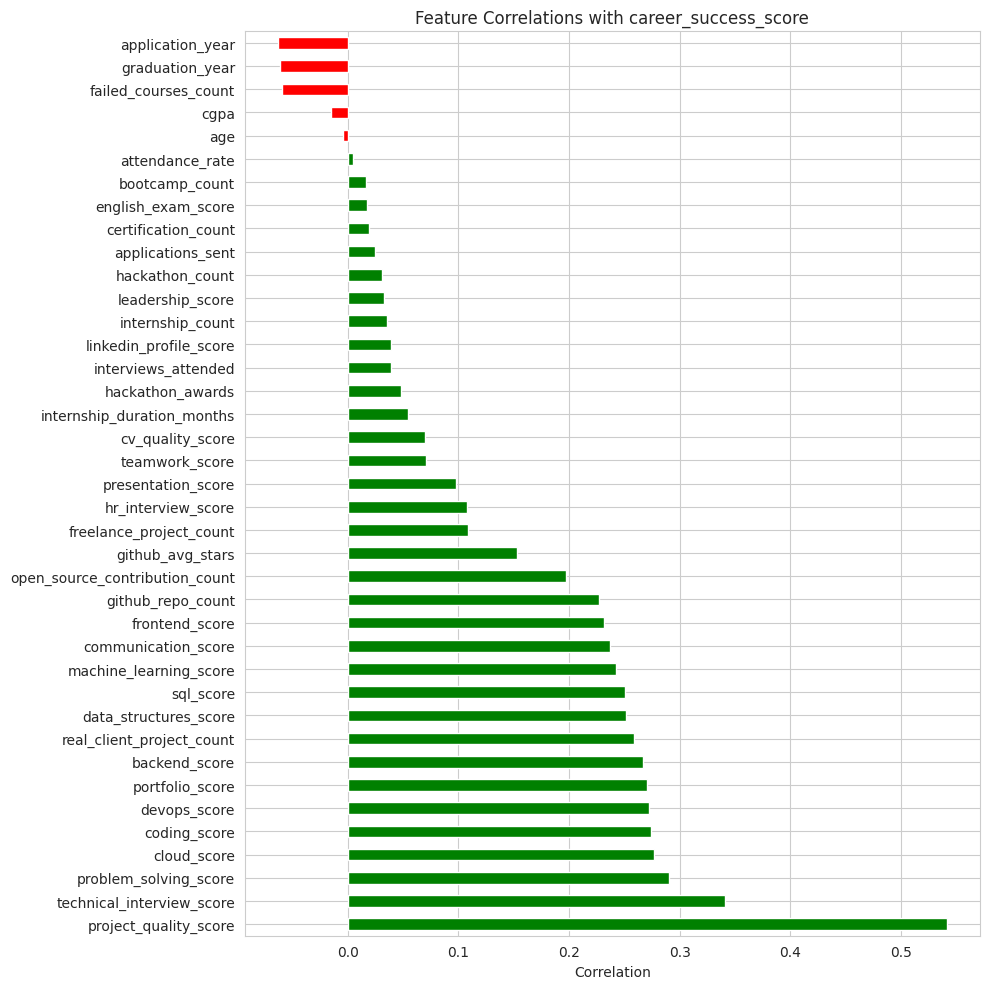

Chart saved to Drive!


In [10]:
# ============================================================
# SECTION 7: CORRELATION ANALYSIS
# ============================================================

# Select only numeric columns
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# Correlation with target, sorted
correlations = train[numeric_cols].corr()[target].drop(target).sort_values(ascending=False)

print("Top 10 positive correlations:")
print(correlations.head(10))
print("\nBottom 5 negative correlations:")
print(correlations.tail(5))

# Visualize
plt.figure(figsize=(10, 10))
colors = ['green' if x > 0 else 'red' for x in correlations]
correlations.plot(kind='barh', color=colors)
plt.title('Feature Correlations with career_success_score')
plt.xlabel('Correlation')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'correlations.png', dpi=150)
plt.show()
print("Chart saved to Drive!")

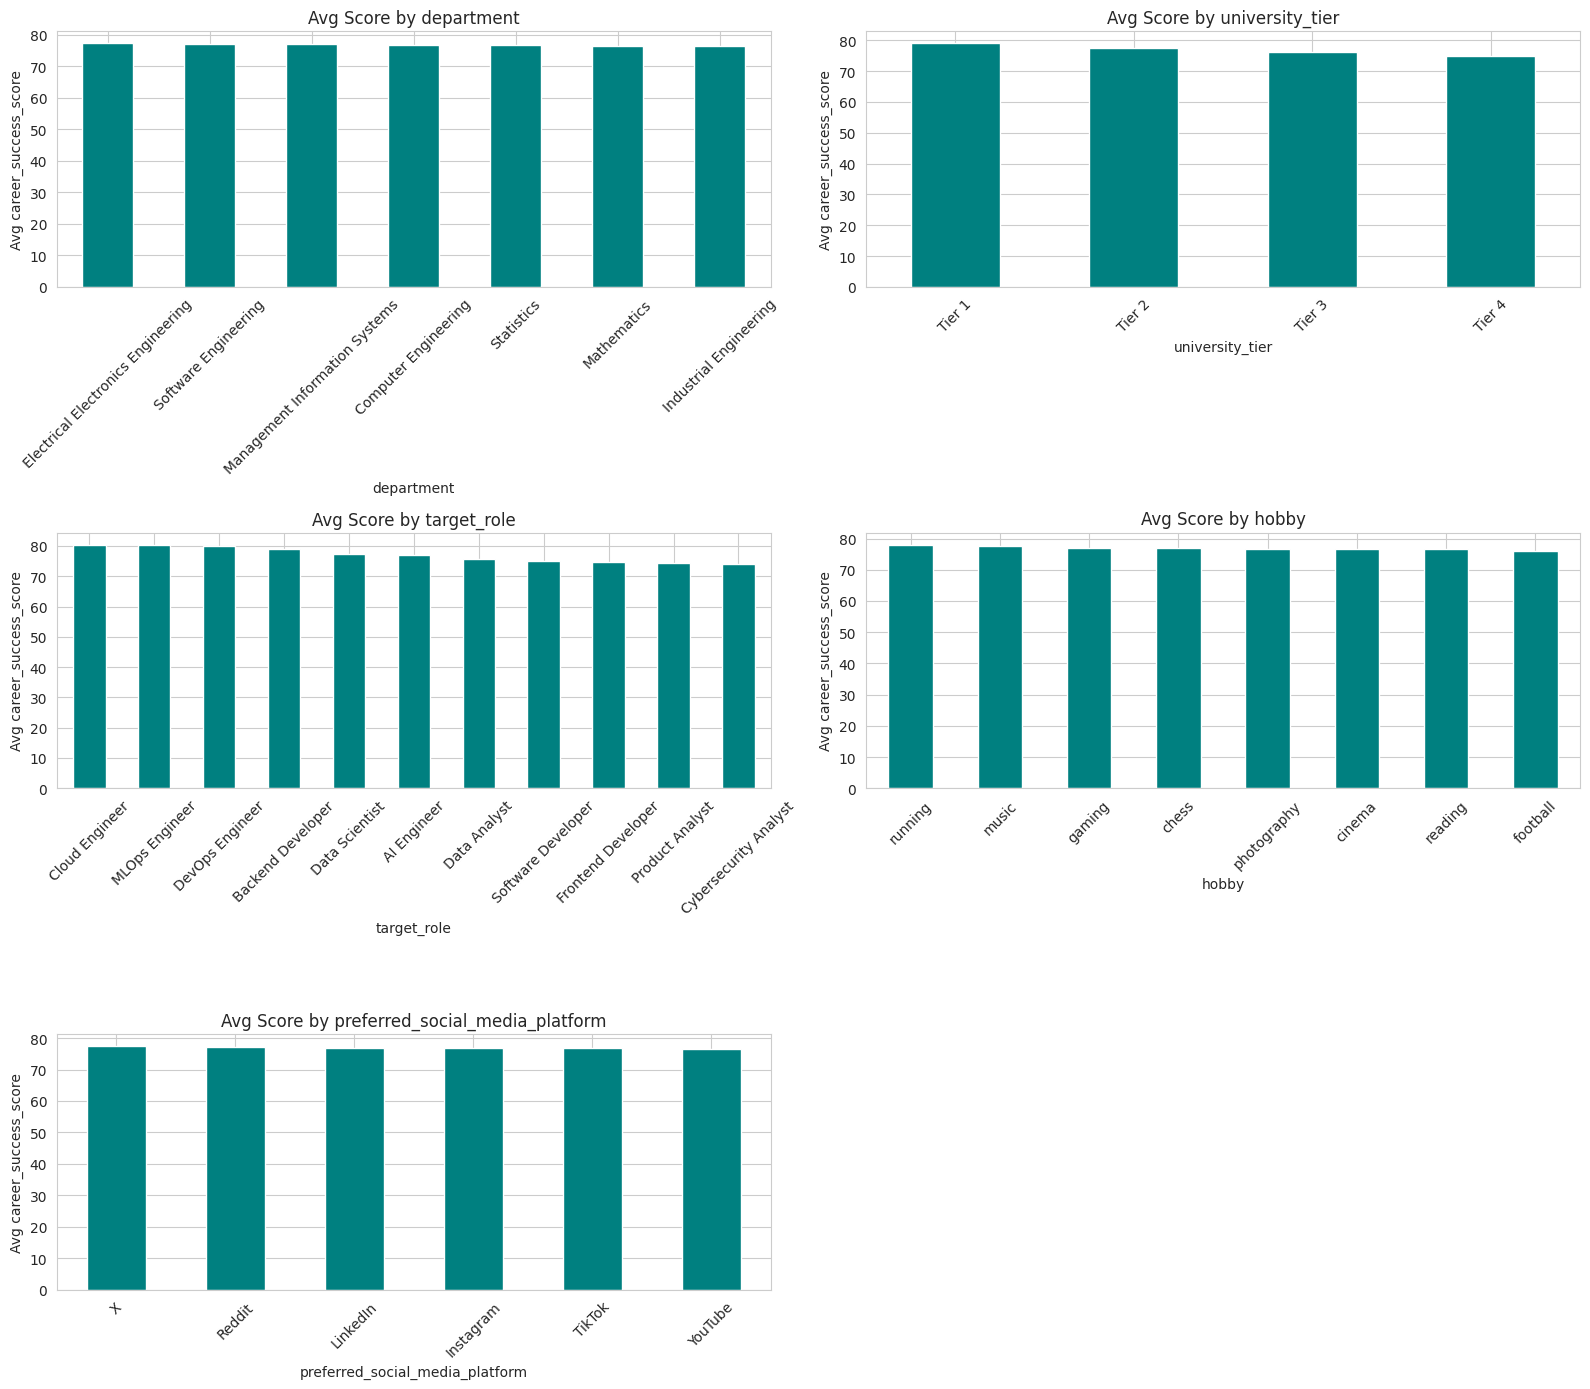

Chart saved!


In [11]:
# ============================================================
# SECTION 8: CATEGORICAL VARIABLE ANALYSIS
# ============================================================

categorical_cols = ['department', 'university_tier', 'target_role',
                    'hobby', 'preferred_social_media_platform']

# Create a 3x2 grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()  # convert 2D grid to 1D list for easy looping

for i, col in enumerate(categorical_cols):
    # Group rows by category, compute mean target score for each group
    means = train.groupby(col)[target].mean().sort_values(ascending=False)
    means.plot(kind='bar', ax=axes[i], color='teal')
    axes[i].set_title(f'Avg Score by {col}')
    axes[i].set_ylabel('Avg career_success_score')
    axes[i].tick_params(axis='x', rotation=45)

# Hide the unused 6th subplot (we have 5 columns, 6 slots)
axes[5].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'categorical_analysis.png', dpi=150)
plt.show()
print("Chart saved!")

In [12]:
# ============================================================
# SECTION 9: FIRST LOOK AT TEXT DATA
# ============================================================

# Print 3 sample feedback texts with their scores
# to manually inspect the relationship between text and score
for i in range(3):
    print(f"--- Student {i+1} | score: {train[target].iloc[i]} ---")
    print(train['mentor_feedback_text'].iloc[i])
    print()

# Does feedback length carry any signal?
train['feedback_length'] = train['mentor_feedback_text'].str.len()
print(f"Avg feedback length: {train['feedback_length'].mean():.0f} characters")
print(f"Correlation (length vs score): {train['feedback_length'].corr(train[target]):.4f}")

--- Student 1 | score: 86.78 ---
Proje kalitesi ve makine öğrenimi konusundaki uzmanlığı dikkat çekici. SQL becerisi ile birlikte, DevOps alanında gelişim gösterse de, veri yapıları ve teknik görüşme sonuçlarında daha fazla çalışma yapması faydalı olacaktır.

--- Student 2 | score: 46.16 ---
Kodlama ve problem çözme becerileri gelişmekte olan bir öğrenci için umut verici, ancak projesinin kalitesi ve iletişim becerileri üzerinde çalışması gerekiyor. Backend geliştirme alanında daha fazla deneyim kazanması kariyerine olumlu bir katkı sağlayabilir.

--- Student 3 | score: 84.08 ---
İleri düzey frontend geliştirme becerileri ile proje bazında önemli deneyimler edinmiş. Ancak, liderlik ve iletişim alanında daha fazla çalışması, kariyer hedeflerini destekleyebilir. Teknik bilgi birikimi yüksek, potansiyeli büyük.

Avg feedback length: 274 characters
Correlation (length vs score): 0.0078


## EDA Findings Summary

### Veri Seti
- Train: 10,000 satır × 47 sütun | Test: 10,000 satır × 46 sütun
- Hedef: career_success_score | Min: 0, Max: 100, Ortalama: 76.94

### Eksik Veriler
- 7 sütunda eksik veri var
- En kritik: internship_duration_months (%16.5), english_exam_score (%9.5)

### Hedef Değişken
- Ortalama ~77, hafif sola çarpık (skewness: -0.45)
- Öğrencilerin %50'si 67-88 arasında skor almış

### Korelasyon Bulguları
- En güçlü sinyal: project_quality_score (0.54)
- Teknik beceriler benzer güçte (0.25-0.34 arası)
- cgpa neredeyse anlamsız (-0.015) — akademik başarı ≠ kariyer başarısı

### Kategorik Değişkenler
- department, university_tier, hobby, social_media: tüm kategoriler ~77 ortalama
- Bu sütunlar gürültü taşıyor, modelde düşük öncelik verilecek

### Metin Verisi (mentor_feedback_text)
- Pozitif kelimeler (dikkat çekici, potansiyel, güçlü) yüksek skorla örtüşüyor
- Negatif kelimeler (ancak, gerekiyor, gelişmekte) düşük skorla örtüşüyor
- feedback_length korelasyonu: 0.0078 → uzunluk anlamsız
- NLP feature engineering'de kelime bazlı analiz yapılacak

In [14]:
# ============================================================
# SECTION 10: PREPROCESSING - MISSING VALUE STRATEGY
# ============================================================

# Hypothesis: internship_duration is missing when student has 0 internships
# Let's verify this before deciding how to fill
missing_duration = train[train['internship_duration_months'].isnull()]
print("Internship counts for rows where duration is missing:")
print(missing_duration['internship_count'].value_counts())

Internship counts for rows where duration is missing:
internship_count
0    1361
1     165
2      87
3      31
4      10
5       3
Name: count, dtype: int64


In [23]:
# ============================================================
# SECTION 11: PREPROCESSING - IMPUTATION & ENCODING
# ============================================================

# ---- STEP 1: COPY DATAFRAMES ----
# Always work on copies to preserve original data for reference
train_processed = train.copy()
test_processed  = test.copy()

# ---- STEP 2: SMART IMPUTATION FOR INTERNSHIP DURATION ----
# Strategy: 0 if no internships, median if internship exists but duration missing

# Calculate median from train only (no data leakage!)
duration_median = train_processed.loc[
    train_processed['internship_count'] > 0,
    'internship_duration_months'
].median()

print(f"Internship duration median (for those with internships): {duration_median}")

# Apply to train
train_processed.loc[
    (train_processed['internship_count'] == 0) &
    (train_processed['internship_duration_months'].isnull()),
    'internship_duration_months'
] = 0

train_processed.loc[
    (train_processed['internship_count'] > 0) &
    (train_processed['internship_duration_months'].isnull()),
    'internship_duration_months'
] = duration_median

# Apply same logic to test (using train's median - no leakage!)
test_processed.loc[
    (test_processed['internship_count'] == 0) &
    (test_processed['internship_duration_months'].isnull()),
    'internship_duration_months'
] = 0

test_processed.loc[
    (test_processed['internship_count'] > 0) &
    (test_processed['internship_duration_months'].isnull()),
    'internship_duration_months'
] = duration_median

# ---- STEP 3: MEDIAN IMPUTATION FOR OTHER NUMERIC COLUMNS ----
# Columns that need median imputation
numeric_to_impute = [
    'english_exam_score',
    'portfolio_score',
    'github_avg_stars',
    'open_source_contribution_count',
    'linkedin_profile_score',
    'hr_interview_score'
]

# Calculate medians from train only, store them for reuse on test
medians = {}
for col in numeric_to_impute:
    medians[col] = train_processed[col].median()
    print(f"{col} median: {medians[col]:.2f}")

# Apply to train
train_processed.fillna(medians, inplace=True)

# Apply same medians to test (not test's own medians!)
test_processed.fillna(medians, inplace=True)

# ---- STEP 4: VERIFY NO MISSING VALUES REMAIN ----
print(f"\nTrain missing after imputation:  {train_processed.isnull().sum().sum()}")
print(f"Test missing after imputation:   {test_processed.isnull().sum().sum()}")

Internship duration median (for those with internships): 8.0
english_exam_score median: 58.12
portfolio_score median: 57.75
github_avg_stars median: 2.55
open_source_contribution_count median: 3.00
linkedin_profile_score median: 53.88
hr_interview_score median: 58.45

Train missing after imputation:  0
Test missing after imputation:   0


In [24]:
# ============================================================
# SECTION 12: CATEGORICAL ENCODING
# ============================================================

# ---- LABEL ENCODING (ordered categories) ----
tier_mapping = {'Tier 1': 4, 'Tier 2': 3, 'Tier 3': 2, 'Tier 4': 1}
train_processed['university_tier'] = train_processed['university_tier'].map(tier_mapping)
test_processed['university_tier']  = test_processed['university_tier'].map(tier_mapping)

print("University tier mapping applied:")
print(train_processed['university_tier'].value_counts().sort_index())

# ---- SEPARATE TARGET BEFORE OHE ----
# Must be done before align() to prevent career_success_score
# from being added to test with fill_value=0
target_col = train_processed['career_success_score'].copy()
train_processed = train_processed.drop(columns=['career_success_score'])

# ---- ONE-HOT ENCODING (unordered categories) ----
ohe_cols = ['department', 'target_role']
train_processed = pd.get_dummies(train_processed, columns=ohe_cols, dtype=int)
test_processed  = pd.get_dummies(test_processed,  columns=ohe_cols, dtype=int)

# Align columns: ensure train and test have identical columns
train_processed, test_processed = train_processed.align(
    test_processed, join='left', axis=1, fill_value=0
)

# ---- DROP NOISE COLUMNS ----
noise_cols = ['hobby', 'preferred_social_media_platform',
              'student_id', 'mentor_feedback_text', 'feedback_length']

for col in noise_cols:
    if col in train_processed.columns:
        train_processed = train_processed.drop(columns=[col])
    if col in test_processed.columns:
        test_processed = test_processed.drop(columns=[col])

# ---- ADD TARGET BACK TO TRAIN ----
train_processed['career_success_score'] = target_col

# ---- FINAL VERIFICATION ----
print(f"\nTrain shape: {train_processed.shape}")
print(f"Test shape:  {test_processed.shape}")

print("\nIn train but not in test:")
print(set(train_processed.columns) - set(test_processed.columns))

print("\nIn test but not in train:")
print(set(test_processed.columns) - set(train_processed.columns))

print(f"\nMissing in train: {train_processed.isnull().sum().sum()}")
print(f"Missing in test:  {test_processed.isnull().sum().sum()}")

University tier mapping applied:
university_tier
1    1572
2    3339
3    3210
4    1879
Name: count, dtype: int64

Train shape: (10000, 59)
Test shape:  (10000, 58)

In train but not in test:
{'career_success_score'}

In test but not in train:
set()

Missing in train: 0
Missing in test:  0


## Preprocessing Summary

### Missing Value Imputation
- internship_duration_months: 0 for students with no internships,
  train median (8.0) for students with internships
- english_exam_score: median = 58.12
- portfolio_score: median = 57.75
- github_avg_stars: median = 2.55
- open_source_contribution_count: median = 3.00
- linkedin_profile_score: median = 53.88
- hr_interview_score: median = 58.45
- Result: 0 missing values in both train and test ✅

### Encoding
- university_tier → Label Encoding (Tier 1=4, Tier 2=3, Tier 3=2, Tier 4=1)
- department, target_role → One-Hot Encoding
- Shape after encoding: Train (10000, 59) | Test (10000, 58)

### Dropped Columns
- hobby, preferred_social_media_platform → no predictive power (EDA)
- student_id → identifier only, not a feature
- mentor_feedback_text → will be used in v3 NLP step
- feedback_length → no correlation with target (0.0078)

### Key Notes
- All medians calculated from train only (no data leakage)
- career_success_score separated before align() to prevent test contamination
- Train and test now have identical feature columns ✅

In [25]:
# ============================================================
# SECTION 13: TRAIN/VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# X = features, y = target
X = train_processed.drop(columns=['career_success_score'])
y = train_processed['career_success_score']

# 80/20 split
# random_state=42: makes the split reproducible (same split every run)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")  # (8000, 58)
print(f"X_val:   {X_val.shape}")    # (2000, 58)
print(f"y_train: {y_train.shape}")  # (8000,)
print(f"y_val:   {y_val.shape}")    # (2000,)

X_train: (8000, 58)
X_val:   (2000, 58)
y_train: (8000,)
y_val:   (2000,)


In [26]:
# ============================================================
# SECTION 14: BASELINE MODEL - XGBOOST
# ============================================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Baseline model with sensible default parameters
model = XGBRegressor(
    n_estimators=500,      # number of trees
    learning_rate=0.05,    # how much each tree contributes
    max_depth=6,           # max depth of each tree
    random_state=42,       # reproducibility
    n_jobs=-1              # use all CPU cores
)

# Train the model
model.fit(X_train, y_train)

# Predict on validation set (data the model has never seen)
val_preds = model.predict(X_val)

# Calculate MSE
val_mse = mean_squared_error(y_val, val_preds)
val_rmse = np.sqrt(val_mse)

print(f"Validation MSE:  {val_mse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}  (avg error in score points)")

Validation MSE:  89.8902
Validation RMSE: 9.4810  (avg error in score points)


In [27]:
# ============================================================
# SECTION 15: PREDICT ON TEST & CREATE SUBMISSION
# ============================================================

# Predict on the real test set
test_preds = model.predict(test_processed)

# Clip predictions to valid range [0, 100]
# Career success score cannot be below 0 or above 100
test_preds = np.clip(test_preds, 0, 100)

# Load original test to get student_id (we dropped it during preprocessing)
test_original = pd.read_csv(DATASET_PATH + 'test_x.csv', encoding='utf-8-sig')

# Build submission dataframe
submission = pd.DataFrame({
    'student_id': test_original['student_id'],
    'career_success_score': test_preds
})

# Save to outputs folder
submission.to_csv(OUTPUT_PATH + 'submission_v1.csv', index=False)

print("Submission created!")
print(submission.head())
print(f"\nShape: {submission.shape}")
print(f"Prediction range: {test_preds.min():.2f} to {test_preds.max():.2f}")
print(f"Prediction mean: {test_preds.mean():.2f}")

Submission created!
   student_id  career_success_score
0  STU_010001             63.411922
1  STU_010002             74.408173
2  STU_010003             76.935623
3  STU_010004             96.668579
4  STU_010005             80.797211

Shape: (10000, 2)
Prediction range: 26.97 to 100.00
Prediction mean: 76.26


## v1 Baseline Results
- Model: XGBoost (n_estimators=500, learning_rate=0.05, max_depth=6)
- Validation MSE: 89.89 | RMSE: 9.48
- **Kaggle Public Score: 99.089303**
- Validation and public scores are close → no overfitting, healthy baseline
- Next: feature engineering (v2) to reduce MSE